# Lets compare the speed of Normal Equation and Gradient Descent

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import time
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler

results = []

for n_features in [10, 100, 1000, 5000]:
    np.random.seed(42)
    X = np.random.randn(10000, n_features)
    w = np.random.randn(n_features)
    y = X @ w + np.random.randn(10000) * 0.6  # Add some noise


    # normal equation
    start_time = time.time()
    lr = LinearRegression()
    lr.fit(X, y)
    normal_eq_time = time.time() - start_time

    # stochastic gradient descent
    start_time = time.time()
    sgd = SGDRegressor(max_iter=1000, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    sgd.fit(X_scaled, y)
    sgd_time = time.time() - start_time

    results.append((n_features, normal_eq_time, sgd_time))

    print(f"Features: {n_features}, Normal Equation Time: {normal_eq_time:.4f}s, SGD Time: {sgd_time:.4f}s")    

Features: 10, Normal Equation Time: 0.3591s, SGD Time: 0.1090s
Features: 100, Normal Equation Time: 1.4676s, SGD Time: 0.1436s
Features: 1000, Normal Equation Time: 3.7306s, SGD Time: 3.2258s
Features: 5000, Normal Equation Time: 67.0791s, SGD Time: 24.7283s


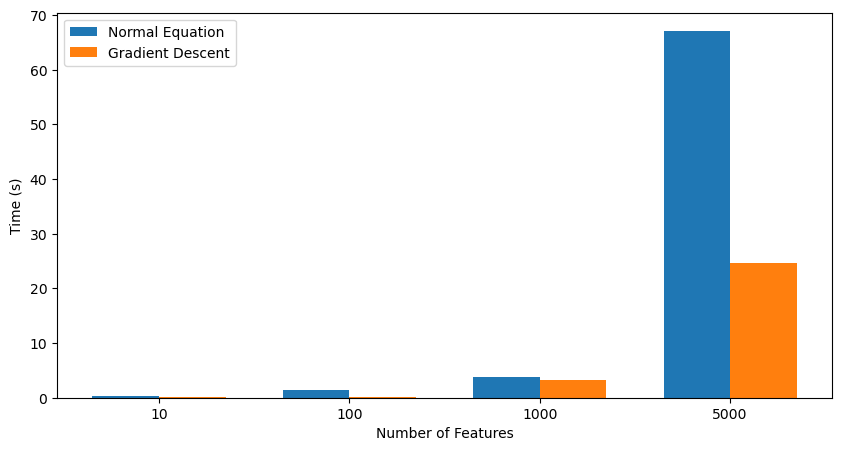

In [3]:
import matplotlib.pyplot as plt
features = [r[0] for r in results]
ne_times = [r[1] for r in results]
gd_times = [r[2] for r in results]

x = np.arange(len(features))  # the label locations
width = 0.35                  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, ne_times, width, label="Normal Equation")
ax.bar(x + width/2, gd_times, width, label="Gradient Descent")
ax.set_xlabel("Number of Features")
ax.set_ylabel("Time (s)")
ax.set_xticks(x)
ax.set_xticklabels(features)
ax.legend()
plt.show()